<a href="https://colab.research.google.com/github/benasphy/DecisionTree/blob/main/Gini_impurity_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree


In [19]:
data = {
    'Energy': ['Low', 'Low', 'Medium', 'Medium', 'High', 'High', 'High', 'Low'],
    'Motivation': ['Low', 'High', 'Low', 'High', 'Low', 'High', 'High', 'High'],
    'Go_Gym': ['No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)
df

,Energy,Motivation,Go_Gym
0,Low,Low,No
1,Low,High,No
2,Medium,Low,No
3,Medium,High,Yes
4,High,Low,Yes
5,High,High,Yes
6,High,High,Yes
7,Low,High,No


In [20]:
le = LabelEncoder()
df["Energy"] = le.fit_transform(df["Energy"])
df["Motivation"] = le.fit_transform(df["Motivation"])
df["Go_Gym"] = le.fit_transform(df["Go_Gym"])
df

,Energy,Motivation,Go_Gym
0,1,1,0
1,1,0,0
2,2,1,0
3,2,0,1
4,0,1,1
5,0,0,1
6,0,0,1
7,1,0,0


In [21]:
X = df[["Energy","Motivation"]]
y = df["Go_Gym"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [23]:
clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred = clf.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

1.0

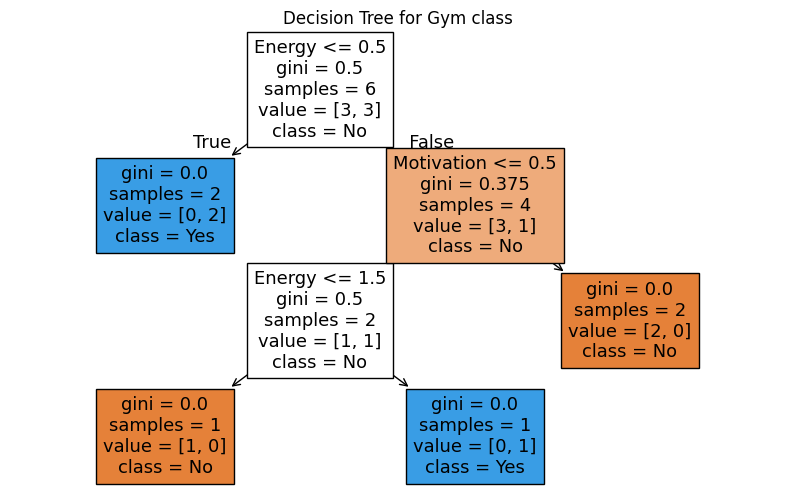

In [27]:
plt.figure(figsize=(10,6))
tree.plot_tree(clf, feature_names=["Energy", "Motivation"], class_names= ["No", "Yes"], filled=True)
plt.title("Decision Tree for Gym class")
plt.show()

In [28]:
# Predict: High Energy (0), High Motivation (1)
sample = [[0, 1]]
prediction = clf.predict(sample)
print("Prediction (1 = Go to gym):", prediction[0])


Prediction (1 = Go to gym): 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
